Gaussian Mixture Model — Repair Invoice

In [1]:
import pandas as pd; 
import numpy as np; 
import matplotlib.pyplot as plt; 
import seaborn as sns; 
from sklearn.preprocessing import StandardScaler, OneHotEncoder; 
from sklearn.mixture import GaussianMixture; 
from sklearn.compose import ColumnTransformer; 
from sklearn.decomposition import PCA; 
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

In [2]:
df = pd.read_csv('repair_invoice_clean.csv')
df.head()

,repair_id,claim_id,vehicle_id,repair_shop_contact_id,estimate_amount,approved_amount,invoice_amount,paid_amount,repair_start_date,repair_end_date,...,exposure_status,is_repeat_vehicle,is_synthetic_anomaly,anomaly_type,vehicle_claim_count,repair_duration_days,vehicle_age,invoice_vs_estimate_ratio,invoice_vs_approved_ratio,duplicate_flag
0,1,1,5749,217,883.00,859.88,821.28,779.60,2025-11-16,2025-11-18,...,Open,False,False,NaN,1,2,13,0.930102,0.955110,True
1,2,2,1818,152,1659.62,1620.74,1627.69,1621.15,2026-02-23,2026-03-02,...,Closed,False,False,NaN,1,7,6,0.980761,1.004288,False
2,7,6,4529,175,1013.25,844.58,917.77,820.13,2026-04-06,2026-04-12,...,Open,False,False,NaN,1,6,3,0.905769,1.086658,False
3,8,6,4529,175,1231.42,1213.63,1417.89,1211.47,2026-04-06,2026-04-12,...,Open,False,False,NaN,1,6,3,1.151427,1.168305,False
4,9,7,7329,180,2946.86,3039.04,2827.41,2918.91,2025-11-23,2025-11-29,...,Closed,False,False,NaN,1,6,4,0.959465,0.930363,False


In [3]:
NUMERIC_FEATURES = [
   "invoice_amount", "estimate_amount",
   "vehicle_age", "liability_percentage",
]
CATEGORICAL_FEATURES = [
   "make", "damage_severity", "claim_severity", "incident_type",
   "incident_state", "coverage_type",
]

In [4]:
preprocessor = ColumnTransformer(transformers=[
        ("num", StandardScaler(), NUMERIC_FEATURES),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
    ])
X = preprocessor.fit_transform(df)

In [5]:
X = X.toarray() if hasattr(X, "toarray") else X
X.shape

(6456, 34)

Choosing the number of components and

In [6]:
component_range = range(2, 21, 2)
bics, aics = [], []

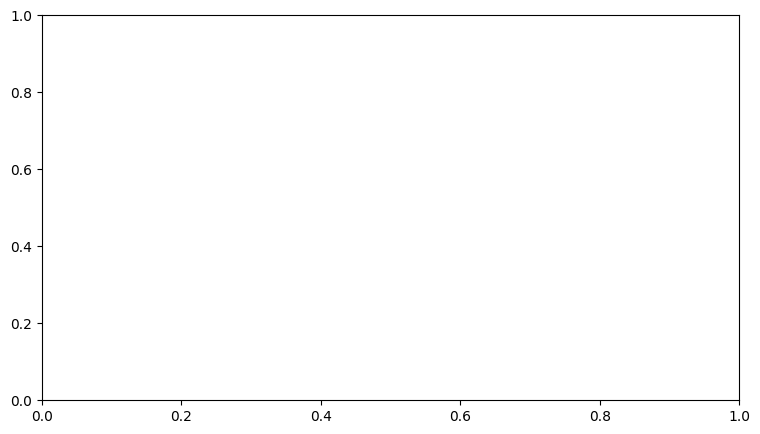

In [7]:
for k in component_range:
    gmm_k = GaussianMixture(n_components=k, covariance_type="diag", random_state=42, n_init=3)
    gmm_k.fit(X)
    bics.append(gmm_k.bic(X))
    aics.append(gmm_k.aic(X))
fig, ax = plt.subplots(figsize=(9, 5))

In [8]:
ax.plot(list(component_range), bics, marker="o", label="BIC"); ax.plot(list(component_range), aics, marker="o", label="AIC"); ax.set_title("GMM model selection"); ax.set_xlabel("n_components"); ax.set_ylabel("score (lower is better)"); ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

<Figure size 640x480 with 0 Axes>

BIC/AIC keep decreasing across the whole

In [9]:
N_COMPONENTS = 14
gmm = GaussianMixture(n_components=N_COMPONENTS, covariance_type="diag", random_state=42, n_init=5)

In [10]:
gmm.fit(X)
labels = gmm.predict(X)

In [11]:
log_likelihood = gmm.score_samples(X)
df["cluster"] = labels

In [12]:
FLAG_PERCENTILE = 5
threshold = np.percentile(log_likelihood, FLAG_PERCENTILE)

In [13]:
df["gmm_flag"] = log_likelihood < threshold
df["gmm_flag"].value_counts()

gmm_flag
False    6133
True      323
Name: count, dtype: int64

In [ ]:
sil = silhouette_score(X, labels)
db = davies_bouldin_score(X, labels)
ch = calinski_harabasz_score(X, labels)
print(f"silhouette={sil:.3f} db={db:.3f} ch={ch:.1f}")

silhouette=-0.000 db=4.840 ch=175.3


In [16]:
print(f"bic={gmm.bic(X):.1f} aic={gmm.aic(X):.1f} avg_log_likelihood={log_likelihood.mean():.2f}")

bic=-983767.5 aic=-990303.2 avg_log_likelihood=76.85


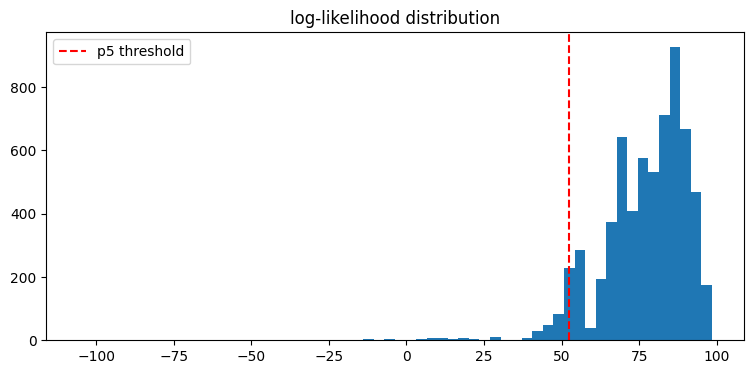

In [17]:
fig, ax = plt.subplots(figsize=(9, 4)); ax.hist(log_likelihood, bins=60); ax.axvline(threshold, color="red", linestyle="--", label=f"p{FLAG_PERCENTILE} threshold"); ax.set_title("log-likelihood distribution"); ax.legend(); plt.show()

In [18]:
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)

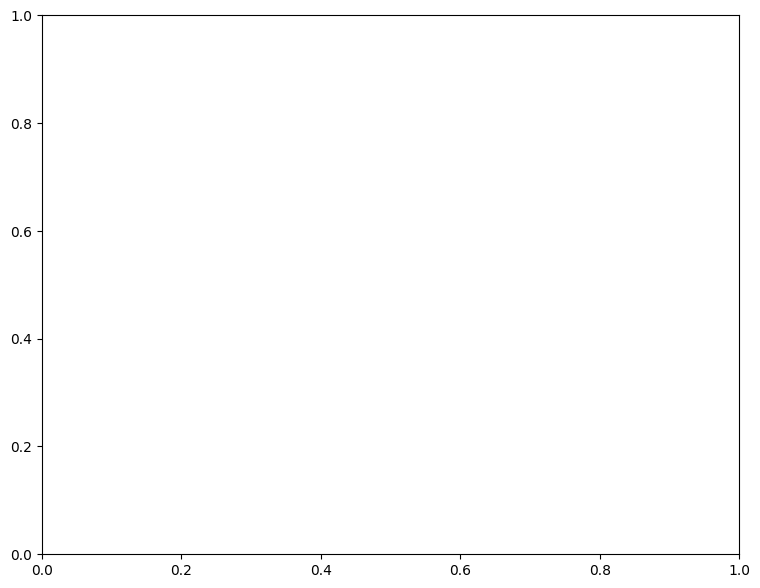

In [19]:
df["pca_1"], df["pca_2"] = X_2d[:, 0], X_2d[:, 1]; fig, ax = plt.subplots(figsize=(9, 7))

In [20]:
normal = df[~df["gmm_flag"]]
flagged = df[df["gmm_flag"]]

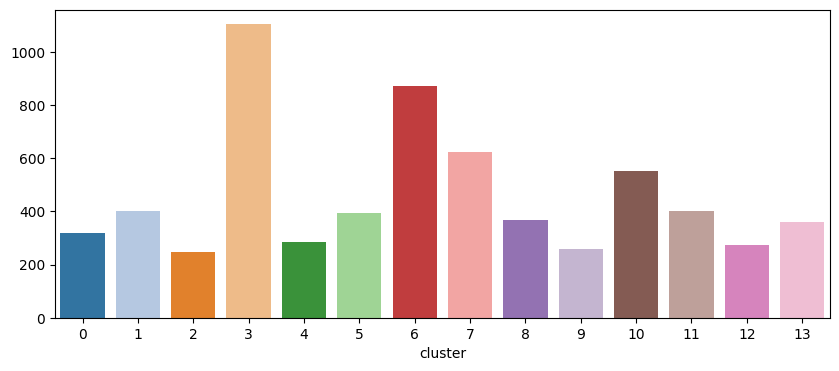

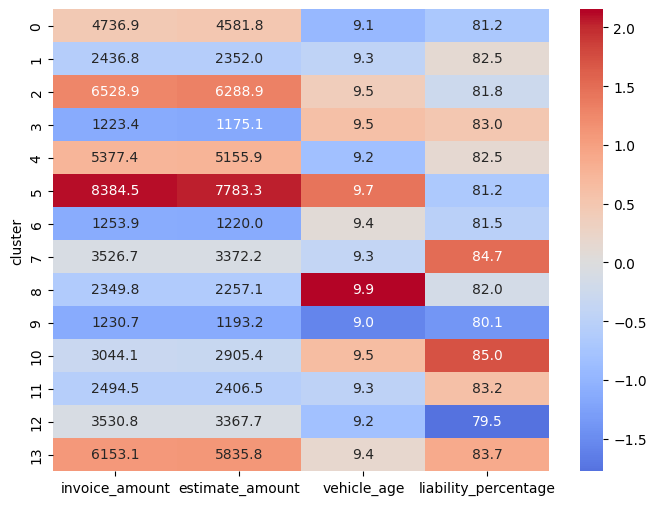

In [21]:
sns.scatterplot(data=normal, x="pca_1", y="pca_2", hue="cluster", palette="tab20", s=25, alpha=0.6, legend=False, ax=ax); ax.scatter(flagged["pca_1"], flagged["pca_2"], facecolors="none", edgecolors="red", s=70, linewidths=1.2, label="gmm_flag"); ax.legend(); plt.show(); cluster_sizes = df["cluster"].value_counts().sort_index(); fig, ax = plt.subplots(figsize=(10, 4)); sns.barplot(x=cluster_sizes.index, y=cluster_sizes.values, hue=cluster_sizes.index, palette="tab20", legend=False, ax=ax); plt.show(); profile = df.groupby("cluster")[NUMERIC_FEATURES].mean(); fig, ax = plt.subplots(figsize=(8, 6)); sns.heatmap((profile - profile.mean()) / profile.std(), cmap="coolwarm", center=0, annot=profile.round(1), fmt="", ax=ax); plt.show()

In [22]:
ct = pd.crosstab(df["gmm_flag"], df["duplicate_flag"], normalize="index")
print(ct.round(3))

duplicate_flag  False  True 
gmm_flag                    
False            0.92   0.08
True             0.92   0.08


0.0804953560371517 0.07992565055762081


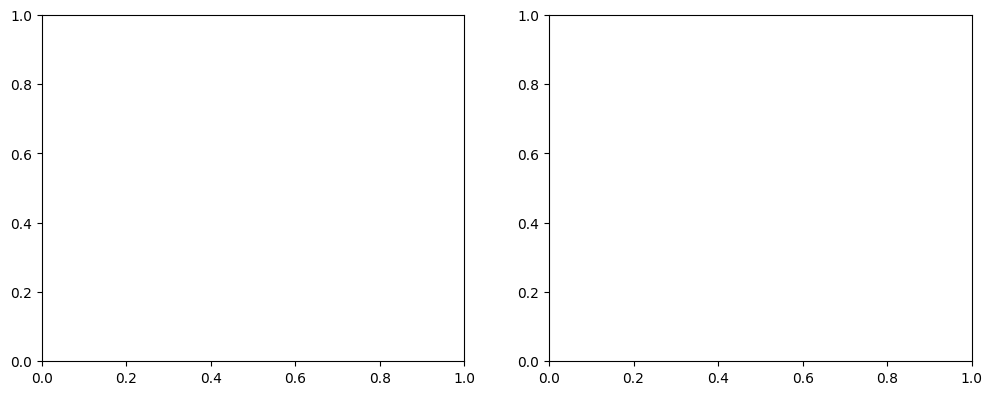

In [23]:
print(df.loc[df["gmm_flag"], "duplicate_flag"].mean(), df["duplicate_flag"].mean()); fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

In [24]:
for ax, col in zip(axes, ["invoice_vs_estimate_ratio", "invoice_vs_approved_ratio"]):
    sns.boxplot(data=df, x="gmm_flag", y=col, ax=ax)
plt.show()

In [25]:
def score_new_point(record):
    row = pd.DataFrame([record])[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
    x_new = preprocessor.transform(row)
    x_new = x_new.toarray() if hasattr(x_new, "toarray") else x_new
    ll = gmm.score_samples(x_new)[0]
    return {"log_likelihood": ll, "threshold": threshold, "gmm_flag": ll < threshold, "pca_coords": pca.transform(x_new)[0].tolist()}

In [26]:
typical_point = {"invoice_amount": 2320.00, "estimate_amount": 2265.50, "vehicle_age": 9, "liability_percentage": 85.0,
    "make": "Toyota", "damage_severity": "Moderate", "claim_severity": "Medium", "incident_type": "Vehicle Accident",
    "incident_state": "CA", "coverage_type": "Liability"}
suspicious_point = {"invoice_amount": 18250.00, "estimate_amount": 2400.00, "vehicle_age": 2, "liability_percentage": 22.0,
    "make": "Tesla", "damage_severity": "Minor", "claim_severity": "Low", "incident_type": "Vehicle Accident",
    "incident_state": "CA", "coverage_type": "Liability"}

In [27]:
for name, point in [("typical", typical_point), ("suspicious", suspicious_point)]:
    print(name, score_new_point(point))

typical {'log_likelihood': 98.37620498218088, 'threshold': 52.310301354099025, 'gmm_flag': False, 'pca_coords': [-0.38956972975326354, 0.18139437405911935]}
suspicious {'log_likelihood': -117.73421443254702, 'threshold': 52.310301354099025, 'gmm_flag': True, 'pca_coords': [3.241256957423615, -1.7155990053044199]}


<Axes: xlabel='pca_1', ylabel='pca_2'>

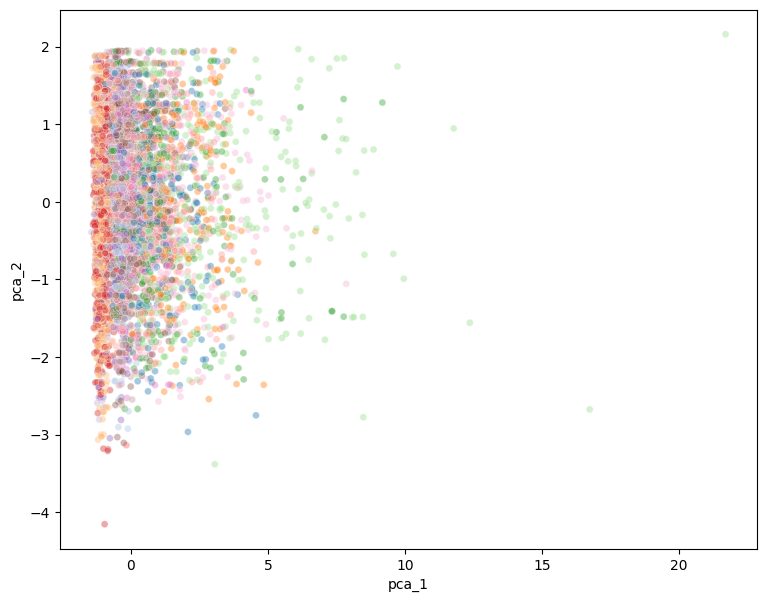

In [ ]:
fig, ax = plt.subplots(figsize=(9, 7)); 
sns.scatterplot(data=df, x="pca_1", y="pca_2", hue="cluster", palette="tab20", s=25, alpha=0.4, legend=False, ax=ax)

In [29]:
for name, point, marker, color in [("typical", typical_point, "*", "limegreen"), ("suspicious", suspicious_point, "X", "red")]:
    r = score_new_point(point)
    px, py = r["pca_coords"]
    ax.scatter(px, py, marker=marker, s=400, color=color, edgecolors="black", label=f"{name} flag={r['gmm_flag']}", zorder=5)
ax.legend()

In [30]:
plt.show()